median_trial_frame 9091.5
10302
36011

RUNNING PIPELINE: PERMUTATION = False
Starting 5-Fold CV (Train & Test Downsampled)...

[Fold 1] Balanced Strata Counts:
  Train: {'0_1_0': 375, '1_0_0': 375, '1_0_1': 375, '0_0_1': 375, '0_0_0': 375, '1_1_0': 375, '0_1_1': 375, '1_1_1': 375}
  Test : {'0_0_0': 37, '0_1_0': 37, '1_0_0': 37, '1_0_1': 37, '1_1_1': 37, '1_1_0': 37}


/home/ross/anaconda3/envs/DLC/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


  Accuracy: 0.6036

[Fold 2] Balanced Strata Counts:
  Train: {'0_0_0': 834, '1_0_0': 834, '1_1_1': 834, '1_1_0': 834, '0_1_1': 834, '1_0_1': 834, '0_0_1': 834, '0_1_0': 834}
  Test : {'1_0_0': 119, '1_1_0': 119}
  Accuracy: 0.7353

[Fold 3] Balanced Strata Counts:
  Train: {'0_1_0': 394, '1_1_0': 394, '1_1_1': 394, '0_0_1': 394, '0_0_0': 394, '1_0_1': 394, '0_1_1': 394, '1_0_0': 394}
  Test : {'1_1_0': 375, '1_0_0': 375, '1_0_1': 375, '1_1_1': 375}
  Accuracy: 0.7120

[Fold 4] Balanced Strata Counts:
  Train: {'1_0_0': 498, '0_0_0': 498, '0_0_1': 498, '1_0_1': 498, '0_1_1': 498, '0_1_0': 498, '1_1_0': 498, '1_1_1': 498}
  Test : {'0_1_0': 336, '0_1_1': 336, '0_0_1': 336, '0_0_0': 336}
  Accuracy: 0.8177

[Fold 5] Balanced Strata Counts:
  Train: {'1_1_0': 336, '1_0_1': 336, '0_1_0': 336, '1_1_1': 336, '0_0_1': 336, '0_1_1': 336, '0_0_0': 336, '1_0_0': 336}
  Test : {'0_0_1': 473, '0_0_0': 473, '0_1_0': 473, '0_1_1': 473}
  Accuracy: 0.5444

Final Mean Accuracy: 0.6826 (+/- 0.0972)

RU

/tmp/ipykernel_2145961/2633951064.py:165: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x='Condition', y='Accuracy', palette=['skyblue', 'lightcoral'], capsize=.1, errorbar='sd')



Results saved to: /home/ross/Documents/lab_projects/s1dz_sociability/notebooks/nds_class_project/sensory_neurons/predict_side/decoding_accuracy_comparison.png


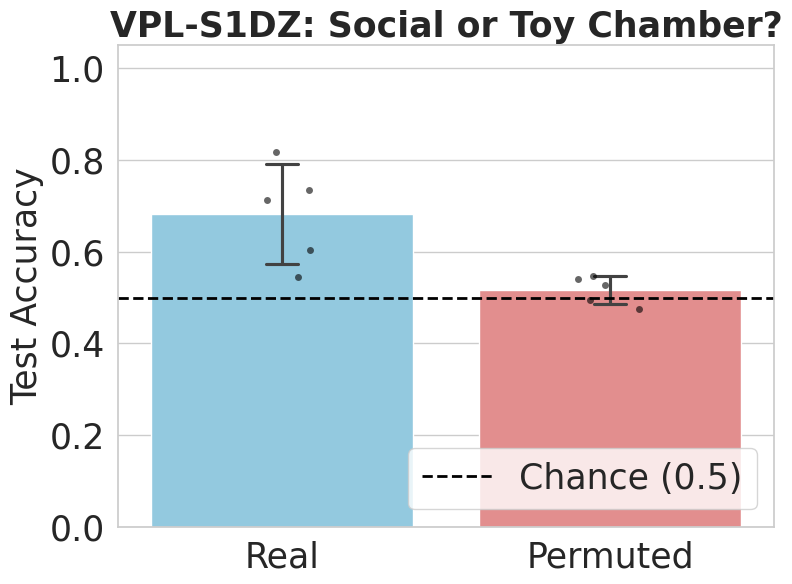

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, StratifiedGroupKFold
from sklearn.utils import resample
import os
import sys
script_path = os.path.abspath("../../../../Library/detrending_zscoring/")
if script_path not in sys.path:
    sys.path.append(script_path)
import detrending_zscoring
# Set plotting style
sns.set_theme(style="whitegrid")

# ==========================================
# 1. Generate / Load Data (Done ONCE outside the loop)
# ==========================================

gaussian_sigma = 25
# Read CSV
behavior_df = pd.read_csv(f"/home/ross/Documents/lab_projects/s1dz_sociability/data/tmp/sensory/x_y_from_crude_method_gaussianSigma{gaussian_sigma}.csv")
read_in_neural = True
if read_in_neural:
    neural_df = pd.read_csv("/home/ross/Documents/lab_projects/s1dz_sociability/data/Sensory S1DZ neurons/sensory_trial1_deconvolved.csv")
else:
    neural_df = pd.read_csv("/home/ross/Documents/lab_projects/s1dz_sociability/data/Sensory S1DZ neurons/Trial #1_Calcium signals.csv")
    import pdb
    pdb.set_trace()
    neural_df = neural_df.iloc[1:, 1:].astype(float)
    neural_df = neural_df.iloc[:len(behavior_df), :]
    # Extract base arrays
    neural_df = neural_df.apply(lambda col:\
        detrending_zscoring.correct_photobleaching_df_plus_deconvolve(col.values))
    neural_df.to_csv("/home/ross/Documents/lab_projects/s1dz_sociability/data/Sensory S1DZ neurons/sensory_trial1_deconvolved.csv", index = False)


# Extract base arrays
raw_neural_data = neural_df.to_numpy(dtype=float)
n_time_steps = raw_neural_data.shape[0]
x_coords = behavior_df["x"].to_numpy()
y_coords = behavior_df["y"].to_numpy()

# Compute Kinematics
dx = np.diff(x_coords, prepend=x_coords[0])
dy = np.diff(y_coords, prepend=y_coords[0])
velocity = np.sqrt(dx**2 + dy**2)
is_moving = np.where(velocity > 0, 1, 0)

# Zone Labeling
is_in_social_area = np.full(n_time_steps, -1)
is_in_social_area[x_coords < 220] = 0
is_in_social_area[x_coords > 450] = 1

near_cage = np.full(n_time_steps, 0)
near_cage[y_coords > 260] = 1

# Create Master DataFrame for filtering
df = pd.DataFrame({
    'original_idx': np.arange(n_time_steps),
    'is_in_social_area': is_in_social_area,
    'is_moving': is_moving,
    'y_coords': y_coords,
    'near_cage': near_cage
})

# Filtering: Remove transitions, keep only stationary, filter by Y-coord
df_filtered = df[(df['is_in_social_area'] == 1)].copy()

# ==========================================
median_trial_frame = df_filtered["original_idx"].median()

# 0 = before median, 1 = after median
df_filtered["before_after_median"] = (df_filtered["original_idx"] >= median_trial_frame).astype(int)
print(f"median_trial_frame {median_trial_frame}")
# Create strata for balancing (Social Zone + Movement state)
df_filtered['strata'] = df_filtered['before_after_median'].astype(str) + "_" + df_filtered['is_moving'].astype(str) + "_" +  df_filtered['near_cage'].astype(str)
strata_filtered = df_filtered['strata'].values
print(len(df_filtered["original_idx"]))
print( len(df))
# Storage for plotting at the end
all_accuracies = []
all_conditions = []

# ==========================================
# 2. Iterative Pipeline (Permutation vs Real)
# ==========================================
for permutation in [False, True]:
    print(f"\n{'='*65}\nRUNNING PIPELINE: PERMUTATION = {permutation}\n{'='*65}")
    
    # Shuffle neural data if permutation run
    neural_data = np.random.permutation(raw_neural_data) if permutation else raw_neural_data.copy()
    X_filtered_all = neural_data[df_filtered['original_idx'].values]

    # CV Configuration: Grouped by time chunks to prevent leakage
    chunk_size = 2500
    groups = np.repeat(np.arange(len(df_filtered) // chunk_size + 1), chunk_size)[:len(df_filtered)]

    n_splits = 5
    cv = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    cv_scores = []
    train_sizes, test_sizes = [], []

    print(f"Starting {n_splits}-Fold CV (Train & Test Downsampled)...")

    for fold, (train_idx, test_idx) in enumerate(cv.split(X_filtered_all, strata_filtered, groups)):
        # Split dataframes
        df_train = df_filtered.iloc[train_idx].copy()
        df_test = df_filtered.iloc[test_idx].copy()
        
        # --- DOWNSAMPLE TRAINING DATA ---
        min_train_size = df_train['strata'].value_counts().min()
        train_groups = []
        for s_val, group in df_train.groupby('strata'):
            train_groups.append(resample(group, replace=False, n_samples=min_train_size))
        df_train_balanced = pd.concat(train_groups).sample(frac=1)
        
        # --- DOWNSAMPLE TEST DATA ---
        min_test_size = df_test['strata'].value_counts().min()
        test_groups = []
        for s_val, group in df_test.groupby('strata'):
            test_groups.append(resample(group, replace=False, n_samples=min_test_size))
        df_test_balanced = pd.concat(test_groups).sample(frac=1)
        
        # Logging
        print(f"\n[Fold {fold+1}] Balanced Strata Counts:")
        print(f"  Train: {df_train_balanced['strata'].value_counts().to_dict()}")
        print(f"  Test : {df_test_balanced['strata'].value_counts().to_dict()}")

        # Map back to neural data
        X_train = neural_data[df_train_balanced['original_idx'].values]
        y_train = df_train_balanced['before_after_median'].values
        X_test = neural_data[df_test_balanced['original_idx'].values]
        y_test = df_test_balanced['before_after_median'].values
        
        # Train and evaluate
        log_reg = LogisticRegression(max_iter=1000, n_jobs=-1)
        log_reg.fit(X_train, y_train)
        score = log_reg.score(X_test, y_test)
        cv_scores.append(score)
        
        print(f"  Accuracy: {score:.4f}")

    print(f"\nFinal Mean Accuracy: {np.mean(cv_scores):.4f} (+/- {np.std(cv_scores):.4f})")
    
    # Store results for final plot
    condition_label = "Permuted" if permutation else "Real"
    all_accuracies.extend(cv_scores)
    all_conditions.extend([condition_label] * len(cv_scores))

# ==========================================
# 3. Visualization
# ==========================================
# Create dataframe for Seaborn
results_df = pd.DataFrame({
    'Accuracy': all_accuracies,
    'Condition': all_conditions
})

plt.figure(figsize=(8, 6))

# Bar plot comparing Real vs Permuted
sns.barplot(data=results_df, x='Condition', y='Accuracy', palette=['skyblue', 'lightcoral'], capsize=.1, errorbar='sd')
# Overlay individual points for each fold
sns.stripplot(data=results_df, x='Condition', y='Accuracy', color='black', alpha=0.6, jitter=True)

plt.axhline(0.5, color='black', linestyle='--', linewidth=2, label='Chance (0.5)')
plt.ylim(0, 1.05)
plt.title(f'VPL-S1DZ: Social or Toy Chamber?', fontsize=25, fontweight='bold')

# --- Updated sizes for labels, ticks, and legend ---
plt.ylabel('Test Accuracy', fontsize=25)
plt.xlabel('')
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)
plt.legend(loc='lower right', fontsize=25)
# ---------------------------------------------------

plt.tight_layout()
out_name = "decoding_accuracy_comparison.png"
plt.savefig(out_name, dpi=300)
print(f"\nResults saved to: {os.path.abspath(out_name)}")

Median Trial Frame: 9091.5
Frames in Social Area: 10302
Total Frames: 36011

Plot saved to: /home/ross/Documents/lab_projects/s1dz_sociability/notebooks/nds_class_project/sensory_neurons/predict_side/median_split_visualization.png


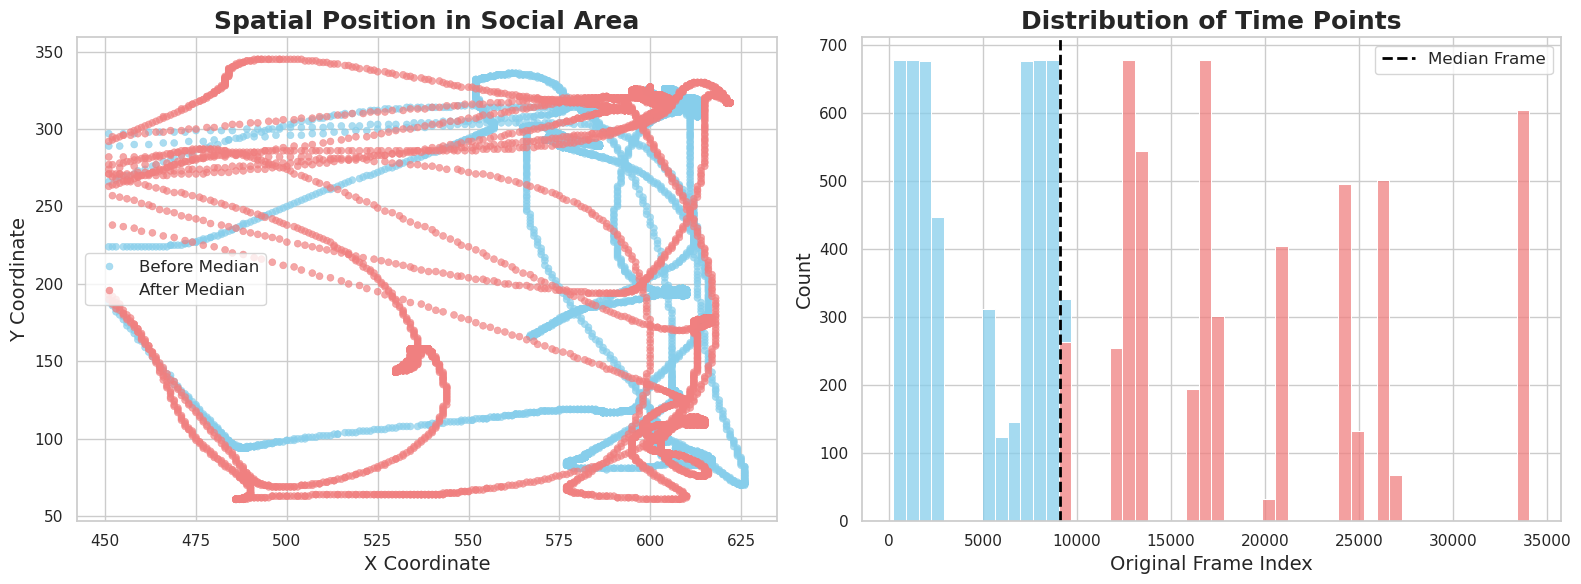

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys

# Optional: Add your custom script path
script_path = os.path.abspath("../../../../Library/detrending_zscoring/")
if script_path not in sys.path:
    sys.path.append(script_path)
import detrending_zscoring

# Set plotting style
sns.set_theme(style="whitegrid")

# ==========================================
# 1. Generate / Load Data
# ==========================================
gaussian_sigma = 25
# Read CSV
behavior_df = pd.read_csv(f"/home/ross/Documents/lab_projects/s1dz_sociability/data/tmp/sensory/x_y_from_crude_method_gaussianSigma{gaussian_sigma}.csv")

read_in_neural = True
if read_in_neural:
    neural_df = pd.read_csv("/home/ross/Documents/lab_projects/s1dz_sociability/data/Sensory S1DZ neurons/sensory_trial1_deconvolved.csv")
else:
    neural_df = pd.read_csv("/home/ross/Documents/lab_projects/s1dz_sociability/data/Sensory S1DZ neurons/Trial #1_Calcium signals.csv")
    neural_df = neural_df.iloc[1:, 1:].astype(float)
    neural_df = neural_df.iloc[:len(behavior_df), :]
    # Extract base arrays and process
    neural_df = neural_df.apply(lambda col: detrending_zscoring.correct_photobleaching_df_plus_deconvolve(col.values))
    neural_df.to_csv("/home/ross/Documents/lab_projects/s1dz_sociability/data/Sensory S1DZ neurons/sensory_trial1_deconvolved.csv", index=False)

# Extract base arrays
raw_neural_data = neural_df.to_numpy(dtype=float)
n_time_steps = raw_neural_data.shape[0]
x_coords = behavior_df["x"].to_numpy()
y_coords = behavior_df["y"].to_numpy()

# Compute Kinematics
dx = np.diff(x_coords, prepend=x_coords[0])
dy = np.diff(y_coords, prepend=y_coords[0])
velocity = np.sqrt(dx**2 + dy**2)
is_moving = np.where(velocity > 0, 1, 0)

# Zone Labeling
is_in_social_area = np.full(n_time_steps, -1)
is_in_social_area[x_coords < 220] = 0
is_in_social_area[x_coords > 450] = 1

near_cage = np.full(n_time_steps, 0)
near_cage[y_coords > 260] = 1

# Create Master DataFrame for filtering
# Note: Added 'x_coords' here so it can be plotted later
df = pd.DataFrame({
    'original_idx': np.arange(n_time_steps),
    'is_in_social_area': is_in_social_area,
    'is_moving': is_moving,
    'x_coords': x_coords, 
    'y_coords': y_coords,
    'near_cage': near_cage
})

# Filtering: keep only social area
df_filtered = df[(df['is_in_social_area'] == 1)].copy()

# ==========================================
# 2. Compute Median and Assign Labels
# ==========================================
median_trial_frame = df_filtered["original_idx"].median()
print(f"Median Trial Frame: {median_trial_frame}")
print(f"Frames in Social Area: {len(df_filtered)}")
print(f"Total Frames: {len(df)}")

# 0 = before median, 1 = after median
df_filtered["before_after_median"] = (df_filtered["original_idx"] >= median_trial_frame).astype(int)

# Create a readable label column for the plot legend
df_filtered["Time Phase"] = df_filtered["before_after_median"].map({
    0: "Before Median", 
    1: "After Median"
})

# ==========================================
# 3. Visualization
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
palette_colors = {'Before Median': 'skyblue', 'After Median': 'lightcoral'}

# Plot A: Spatial Coordinates (X vs Y)
sns.scatterplot(
    data=df_filtered, 
    x='x_coords', 
    y='y_coords', 
    hue='Time Phase', 
    palette=palette_colors,
    s=25, 
    alpha=0.7, 
    edgecolor=None,
    ax=axes[0]
)
axes[0].set_title('Spatial Position in Social Area', fontsize=18, fontweight='bold')
axes[0].set_xlabel('X Coordinate', fontsize=14)
axes[0].set_ylabel('Y Coordinate', fontsize=14)
axes[0].legend(fontsize=12)

# Plot B: Temporal Histogram (Index distribution)
sns.histplot(
    data=df_filtered, 
    x='original_idx', 
    hue='Time Phase', 
    palette=palette_colors,
    bins=50, 
    multiple="stack",
    ax=axes[1]
)
axes[1].axvline(median_trial_frame, color='black', linestyle='--', linewidth=2, label='Median Frame')
axes[1].set_title('Distribution of Time Points', fontsize=18, fontweight='bold')
axes[1].set_xlabel('Original Frame Index', fontsize=14)
axes[1].set_ylabel('Count', fontsize=14)
axes[1].legend(fontsize=12)

plt.tight_layout()
out_name = "median_split_visualization.png"
plt.savefig(out_name, dpi=300)
print(f"\nPlot saved to: {os.path.abspath(out_name)}")
plt.show()

Total Frames in Trial: 36011
Social Area (1) Frames: 10302 (Median Frame: 9091.5)
Toy Chamber (0) Frames: 20273 (Median Frame: 21571.0)

Plot saved to: /home/ross/Documents/lab_projects/s1dz_sociability/notebooks/nds_class_project/sensory_neurons/predict_side/social_vs_toy_median_split.png


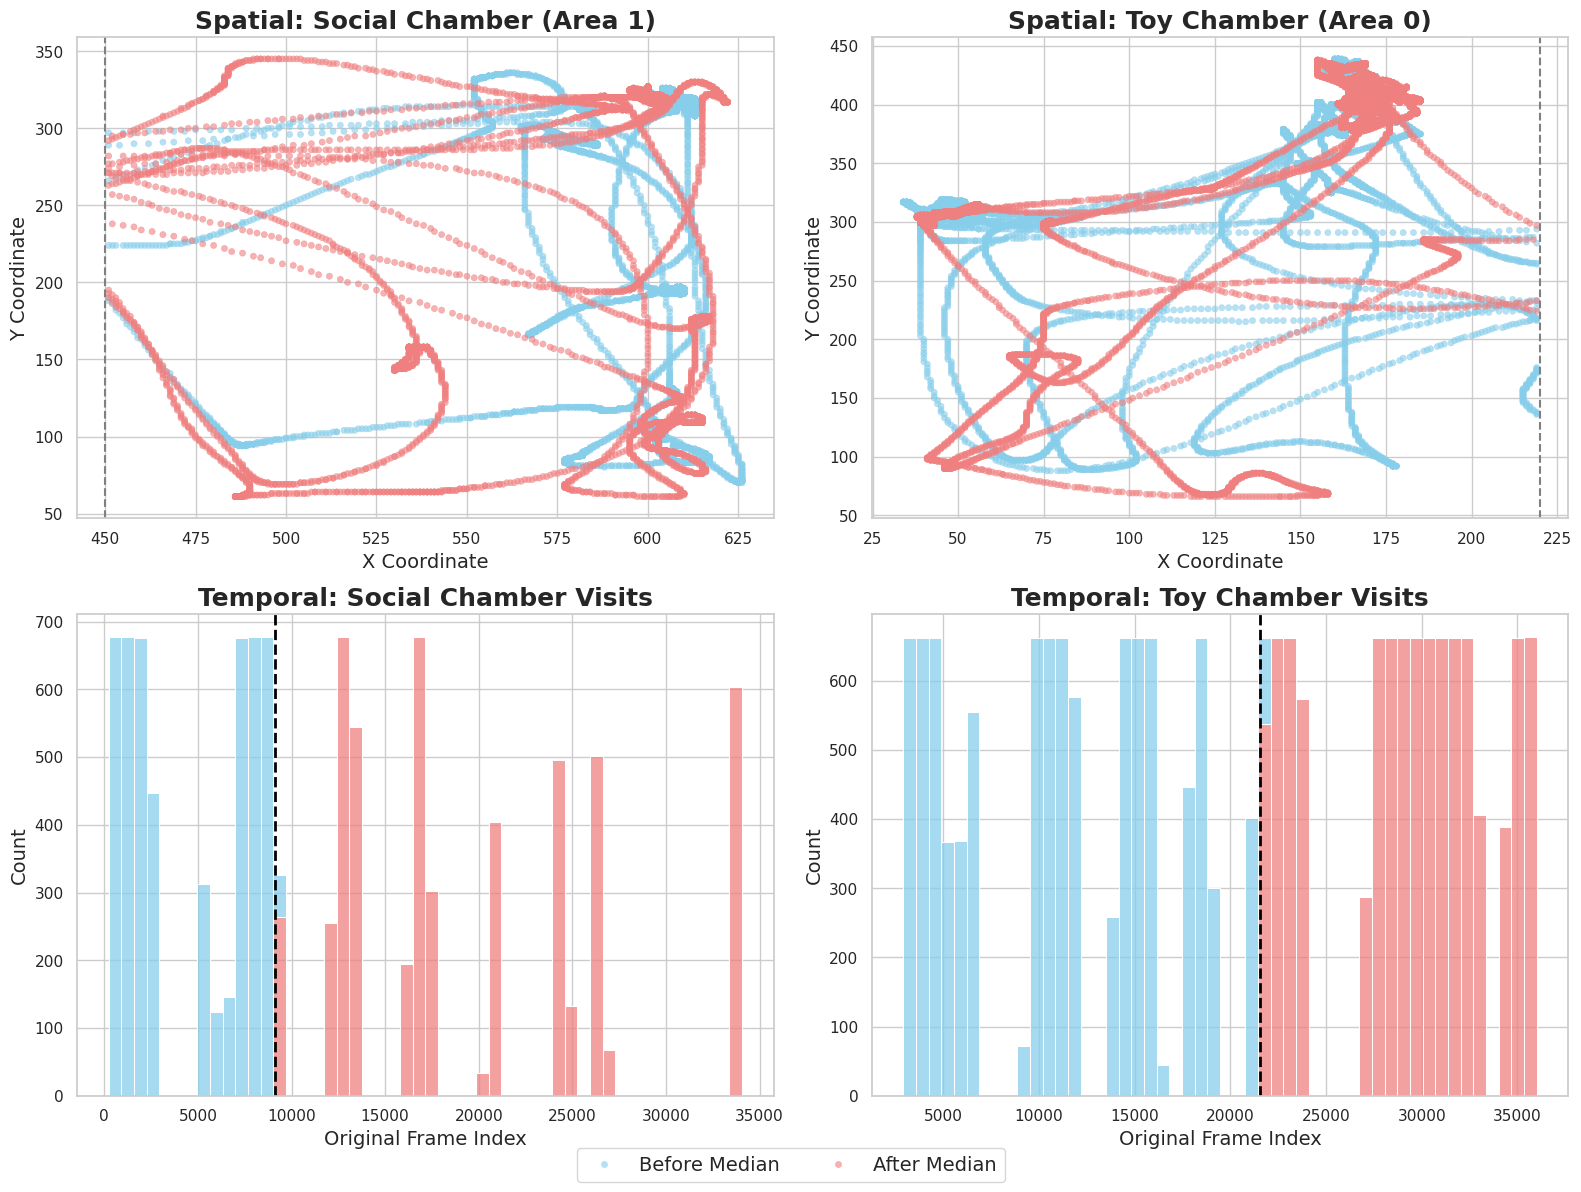

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys

# Optional: Add custom script path
script_path = os.path.abspath("../../../../Library/detrending_zscoring/")
if script_path not in sys.path:
    sys.path.append(script_path)
import detrending_zscoring

# Set plotting style
sns.set_theme(style="whitegrid")

# ==========================================
# 1. Generate / Load Data
# ==========================================
gaussian_sigma = 25
# Read CSV
# Note: Adjust paths as necessary for your system
behavior_df = pd.read_csv(f"/home/ross/Documents/lab_projects/s1dz_sociability/data/tmp/sensory/x_y_from_crude_method_gaussianSigma{gaussian_sigma}.csv")

read_in_neural = True
if read_in_neural:
    neural_df = pd.read_csv("/home/ross/Documents/lab_projects/s1dz_sociability/data/Sensory S1DZ neurons/sensory_trial1_deconvolved.csv")
else:
    # Dummy placeholder for neural loading logic provided in original snippet
    neural_df = pd.DataFrame(np.random.randn(len(behavior_df), 10)) 
    print("WARNING: Using dummy neural data for structure.")

n_time_steps = neural_df.shape[0]
x_coords = behavior_df["x"].to_numpy()
y_coords = behavior_df["y"].to_numpy()

# Compute Kinematics
dx = np.diff(x_coords, prepend=x_coords[0])
dy = np.diff(y_coords, prepend=y_coords[0])
velocity = np.sqrt(dx**2 + dy**2)
is_moving = np.where(velocity > 0, 1, 0)

# Zone Labeling (0 = Toy, 1 = Social, -1 = Neutral)
is_in_social_area = np.full(n_time_steps, -1)
is_in_social_area[x_coords < 220] = 0
is_in_social_area[x_coords > 450] = 1

near_cage = np.full(n_time_steps, 0)
near_cage[y_coords > 260] = 1

# Create Master DataFrame containing all behavior
df = pd.DataFrame({
    'original_idx': np.arange(n_time_steps),
    'is_in_social_area': is_in_social_area,
    'is_moving': is_moving,
    'x_coords': x_coords, 
    'y_coords': y_coords,
    'near_cage': near_cage
})

# ==========================================
# 2. Process Subsets (Social vs Toy)
# ==========================================
# Helper mapping for readability
phase_map = {0: "Before Median", 1: "After Median"}

print(f"Total Frames in Trial: {len(df)}")

# --- Subset 1: Social Area (is_in_social_area == 1) ---
df_social = df[df['is_in_social_area'] == 1].copy()
median_social = df_social["original_idx"].median()
# Label before/after based on the local median of social visits
df_social["before_after_median"] = (df_social["original_idx"] >= median_social).astype(int)
df_social["Time Phase"] = df_social["before_after_median"].map(phase_map)
print(f"Social Area (1) Frames: {len(df_social)} (Median Frame: {median_social})")

# --- Subset 2: Toy Chamber (is_in_social_area == 0) ---
df_toy = df[df['is_in_social_area'] == 0].copy()
median_toy = df_toy["original_idx"].median()
# Label before/after based on the local median of toy visits
df_toy["before_after_median"] = (df_toy["original_idx"] >= median_toy).astype(int)
df_toy["Time Phase"] = df_toy["before_after_median"].map(phase_map)
print(f"Toy Chamber (0) Frames: {len(df_toy)} (Median Frame: {median_toy})")

# ==========================================
# 3. Visualization (2x2 Grid)
# ==========================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
palette_colors = {'Before Median': 'skyblue', 'After Median': 'lightcoral'}

# Style settings for all subplots
title_font = {'fontsize': 18, 'fontweight': 'bold'}
label_font = {'fontsize': 14}

# ------------------------------------------------------------------
# ROW 1: SPATIAL COORDINATES (Mouse Trajectory)
# ------------------------------------------------------------------

# Top-Left: Social Area Spatial
sns.scatterplot(
    data=df_social, x='x_coords', y='y_coords', hue='Time Phase', 
    palette=palette_colors, s=20, alpha=0.6, edgecolor=None, ax=axes[0, 0]
)
# Add boundary line for context (x > 450)
axes[0, 0].axvline(450, color='gray', linestyle='--')
axes[0, 0].set_title('Spatial: Social Chamber (Area 1)', **title_font)
axes[0, 0].set_xlabel('X Coordinate', **label_font)
axes[0, 0].set_ylabel('Y Coordinate', **label_font)

# Top-Right: Toy Chamber Spatial
sns.scatterplot(
    data=df_toy, x='x_coords', y='y_coords', hue='Time Phase', 
    palette=palette_colors, s=20, alpha=0.6, edgecolor=None, ax=axes[0, 1]
)
# Add boundary line for context (x < 220)
axes[0, 1].axvline(220, color='gray', linestyle='--')
axes[0, 1].set_title('Spatial: Toy Chamber (Area 0)', **title_font)
axes[0, 1].set_xlabel('X Coordinate', **label_font)
axes[0, 1].set_ylabel('Y Coordinate', **label_font)

# ------------------------------------------------------------------
# ROW 2: TEMPORAL DISTRIBUTION (Over time)
# ------------------------------------------------------------------

# Bottom-Left: Social Area Temporal Histogram
sns.histplot(
    data=df_social, x='original_idx', hue='Time Phase', palette=palette_colors,
    bins=50, multiple="stack", ax=axes[1, 0], legend=False
)
axes[1, 0].axvline(median_social, color='black', linestyle='--', linewidth=2, label='Local Median')
axes[1, 0].set_title('Temporal: Social Chamber Visits', **title_font)
axes[1, 0].set_xlabel('Original Frame Index', **label_font)
axes[1, 0].set_ylabel('Count', **label_font)

# Bottom-Right: Toy Chamber Temporal Histogram
sns.histplot(
    data=df_toy, x='original_idx', hue='Time Phase', palette=palette_colors,
    bins=50, multiple="stack", ax=axes[1, 1], legend=False
)
axes[1, 1].axvline(median_toy, color='black', linestyle='--', linewidth=2, label='Local Median')
axes[1, 1].set_title('Temporal: Toy Chamber Visits', **title_font)
axes[1, 1].set_xlabel('Original Frame Index', **label_font)
axes[1, 1].set_ylabel('Count', **label_font)


# Final aesthetic cleanups
plt.tight_layout()
# Move legends to bottom center
handles, labels = axes[0,0].get_legend_handles_labels()
axes[0,0].get_legend().remove()
axes[0,1].get_legend().remove()
fig.legend(handles, labels, loc='lower center', ncol=2, fontsize=14, frameon=True)
plt.subplots_adjust(bottom=0.08) # Make space for figure legend

out_name = "social_vs_toy_median_split.png"
plt.savefig(out_name, dpi=300)
print(f"\nPlot saved to: {os.path.abspath(out_name)}")
plt.show()

In [23]:
np.unique(is_in_social_area, return_counts =True)

(array([-1,  0,  1]), array([ 5436, 20273, 10302]))